# Question 2 — Analyse bivariée et régression linéaire

**Fichiers :**
- Volet 1 : `src/models/analyse_bivariate.py`
- Volet 2 : `src/models/comparaison_modeles_q2.py` (régression linéaire uniquement)

In [1]:
import sys
from pathlib import Path

RACINE = Path.cwd().resolve()
if RACINE.name == "notebooks":
    RACINE = RACINE.parent
sys.path.insert(0, str(RACINE))

import matplotlib.pyplot as plt
from src.data.chargement import charger_donnees_brutes, chemin_figures
from src.models.analyse_bivariate import executer_analyse_bivariate

df = charger_donnees_brutes()
df.head()

,Notes,Assiduité,target
0,14.5,69.0,1
1,3.7,16.0,0
2,9.8,48.0,0
3,7.0,38.0,0
4,3.3,21.0,0


## Volet 1 — Vérifier le lien Assiduité ↔ Notes

In [2]:
q2_v1 = executer_analyse_bivariate()
b = q2_v1["bivariate"]
print(f"Pearson  : {b['pearson']:.4f}")
print(f"Spearman : {b['spearman']:.4f}")
print(f"Covariance : {b['covariance']:.4f}")
print(q2_v1["message_lien"])
b["matrice_correlation"]

Pearson  : 0.9864
Spearman : 0.9862
Covariance : 169.7255
Corrélation r = 0.986 → relation très forte. Le lien est bien vérifié dans les données.


,Notes,Assiduité
Notes,1.000000,0.986378
Assiduité,0.986378,1.000000


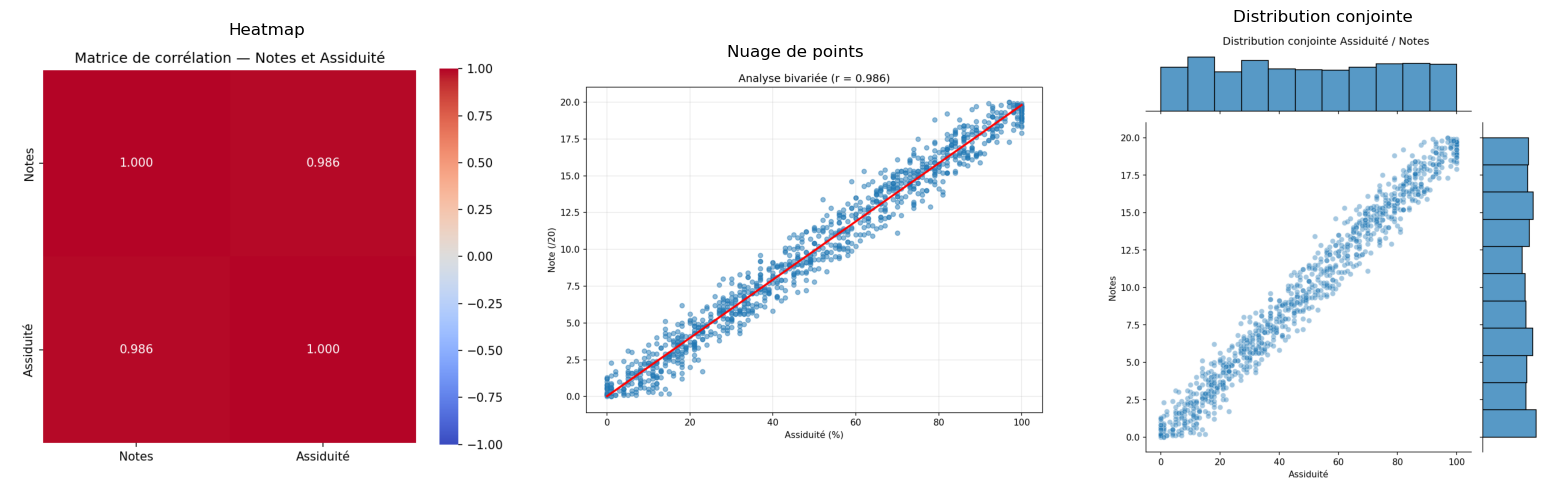

In [3]:
dossier = chemin_figures()
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, f, t in zip(
    axes,
    ["heatmap_correlation_bivariee.png", "nuage_points_assiduite_notes.png", "jointplot_assiduite_notes.png"],
    ["Heatmap", "Nuage de points", "Distribution conjointe"],
):
    ax.imshow(plt.imread(dossier / f))
    ax.axis("off")
    ax.set_title(t)
plt.tight_layout()
plt.show()

## Volet 2 — Régression linéaire

Modèle retenu : **Notes = a × Assiduité + b** (conforme au sujet du TP, Section 5).

In [4]:
from src.models.comparaison_modeles_q2 import (
    executer_regression_lineaire,
    rapport_ols,
    seuil_incertitude_acceptable,
)

q2_v2 = executer_regression_lineaire()
m = q2_v2["metriques"]
print(f"RMSE = {m['rmse']:.3f} | MAE = {m['mae']:.3f} | R² = {m['r2']:.4f}")
print(f"Équation : {q2_v2['regression_lineaire']['equation']}")
print(q2_v2["modele_retenu"]["justification"])
print(seuil_incertitude_acceptable(m["rmse"]))

RMSE = 1.021 | MAE = 0.835 | R² = 0.9686
Équation : Notes ≈ 0.198 × Assiduité + 0.015
Modèle retenu : Régression linéaire (RMSE = 1.021 pts, R² = 0.9686)
RMSE = 1.02 pts (< 2.0) : anticipation utilisable avec prudence.


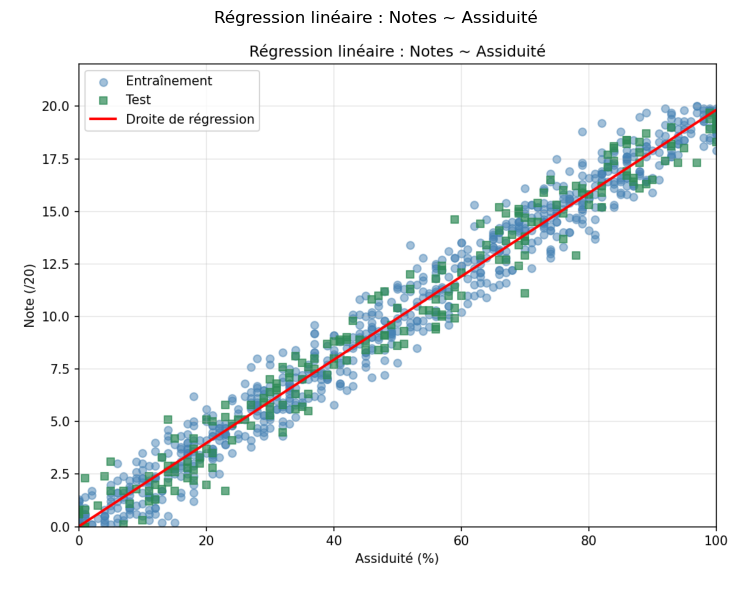

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(plt.imread(dossier / "regression_lineaire_notes_assiduite.png"))
ax.axis("off")
ax.set_title("Régression linéaire : Notes ~ Assiduité")
plt.tight_layout()
plt.show()

In [6]:
print(rapport_ols(df).summary())

                            OLS Regression Results                            
Dep. Variable:                  Notes   R-squared:                       0.974
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                 2.984e+04
Date:                Sun, 05 Jul 2026   Prob (F-statistic):               0.00
Time:                        22:05:48   Log-Likelihood:                -1095.3
No. Observations:                 800   AIC:                             2195.
Df Residuals:                     798   BIC:                             2204.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0146      0.067      0.220      0.8

## Interprétation

- Le lien assiduité/note est **très fort** (Pearson proche de 1).
- La régression linéaire estime la note avec une erreur moyenne d'environ **1 point sur 20**.
- **+10 points d'assiduité** ≈ **+2 points de note** (coefficient ≈ 0,20).
- Au-delà de **2 points d'erreur** (RMSE), l'anticipation ne doit pas fonder une décision seule.